# Complete Exploratory Data Analysis

This is where your full EDA goes. We look forward to digging deeper into your analysis here. 

Read the [eda_outline.md](eda_outline.md) for more details.

In [1]:
# Dependencies

from contextlib import contextmanager
from datetime import datetime
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import polars as pl
import psutil
import seaborn as sns
import numpy as np
import pandas as pd

import eda_starter as eda

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

from xgboost import XGBRegressor
import shap

## Part 1: On-chain and Macro Metrics

Load dataset

In [2]:
btc_df = eda.load_bitcoin_data(eda.COINMETRICS_PATH)

Loading Bitcoin data from C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\data\Coin Metrics\coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 271.51 MB
[Memory] After loading Bitcoin data: 305.11 MB (Δ 33.60 MB)
Successfully loaded 6221 rows.


In [3]:
btc_df = btc_df.filter(pl.col("PriceUSD").is_not_null())
btc_df = btc_df.with_columns(
    pl.col("PriceUSD").shift(-1).alias("lag_1d"),
    pl.col("PriceUSD").shift(-2).alias("lag_2d"),
    pl.col("PriceUSD").shift(-3).alias("lag_3d"),
    pl.col("PriceUSD").shift(-7).alias("lag_7d"),
    pl.col("PriceUSD").shift(-30).alias("lag_30d"),
)
btc_df = btc_df.with_columns(
    (pl.col("lag_1d")-pl.col("PriceUSD")).alias("delta_1d"),
    (pl.col("lag_2d")-pl.col("PriceUSD")).alias("delta_2d"),
    (pl.col("lag_3d")-pl.col("PriceUSD")).alias("delta_3d"),
    (pl.col("lag_3d")-pl.col("PriceUSD")).alias("delta_7d"),
    (pl.col("lag_30d")-pl.col("PriceUSD")).alias("delta_30d"),
    ((pl.col("lag_1d")-pl.col("PriceUSD"))/pl.col("PriceUSD")).alias("change_1d"),
    ((pl.col("lag_2d")-pl.col("PriceUSD"))/pl.col("PriceUSD")).alias("change_2d"),
    ((pl.col("lag_3d")-pl.col("PriceUSD"))/pl.col("PriceUSD")).alias("change_3d"),
    ((pl.col("lag_7d")-pl.col("PriceUSD"))/pl.col("PriceUSD")).alias("change_7d"),
    ((pl.col("lag_30d")-pl.col("PriceUSD"))/pl.col("PriceUSD")).alias("change_30d")
)

In [4]:
btc_df.describe()

statistic,time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,FlowInExUSD,FlowOutExNtv,FlowOutExUSD,HashRate,IssTotNtv,IssTotUSD,PriceBTC,PriceUSD,ROI1yr,ROI30d,ReferenceRate,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,lag_1d,lag_2d,lag_3d,lag_7d,lag_30d,delta_1d,delta_2d,delta_3d,delta_7d,delta_30d,change_1d,change_2d,change_3d,change_7d,change_30d
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""","""5659""",5659.0,5659.0,5659.0,5659.0,5659.0,5659.0,5659.0,2398.0,5659.0,5659.0,5659.0,5659.0,5659.0,5659.0,5659.0,5659.0,5659.0,5659.0,5294.0,5629.0,6.0,6.0,6.0,6.0,5659.0,5659.0,5659.0,5659.0,5659.0,5659.0,5659.0,5658.0,5657.0,5656.0,5652.0,5629.0,5658.0,5657.0,5656.0,5656.0,5629.0,5658.0,5657.0,5656.0,5652.0,5629.0
"""null_count""","""0""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,3261.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,365.0,30.0,5653.0,5653.0,5653.0,5653.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,3.0,7.0,30.0,1.0,2.0,3.0,3.0,30.0,1.0,2.0,3.0,7.0,30.0
"""mean""","""2018-04-16 00:00:00""",550543.072451,2.2869e7,1.6386e9,1.6386e9,152.571126,1.989795,3.8264e11,8.6339e11,53.007091,28400.488003,5.0364e8,29211.835042,5.5848e8,1.6631e8,2922.12902,1.5181e7,1.0,19809.987841,559.643271,14.638035,90851.66237,29.240772,78021.16538,90851.66237,1.5462e7,1.0420e6,4.0124e10,2.0027e7,229071.955292,546387.064676,5.1167e9,19813.489061,19816.991519,19820.495218,19834.522416,19915.565687,16.844187,32.958367,49.003291,49.003291,475.335706,0.003575,0.007218,0.010886,0.026426,0.14638
"""std""",null,361838.276514,1.9350e7,4.3640e7,4.3640e7,21.654898,2.493876,5.8737e11,6.3984e11,94.252698,24087.189584,8.1787e8,24355.416302,9.5674e8,2.7156e8,2637.126077,1.7091e7,0.0,29699.078673,1944.97263,55.521166,342.215931,0.227712,160.427347,342.215931,4.3665e6,798630.205089,7.3427e10,758078.519299,164751.644393,355315.492206,7.5850e9,29700.535516,29701.992389,29703.449292,29709.2772,29742.796527,933.901409,1299.754629,1583.243473,1583.243473,5136.965841,0.047221,0.068378,0.08564,0.144694,0.555212
"""min""","""2010-07-18 00:00:00""",408.0,52190.0,1.6143e9,1.6143e9,58.0,0.386829,177670.489754,9.0586e10,0.0,0.0,0.0,0.0,0.0,0.001552,334.375,307.0,1.0,0.050541,-83.730494,-61.668266,90406.142411,28.832312,77790.505193,90406.142411,3.4478e6,0.0,0.0,1.7932e7,94.0,147.0,0.0,0.050541,0.050541,0.050541,0.050541,0.06,-8012.078893,-10663.219138,-12450.239447,-12450.239447,-27122.54985,-0.485699,-0.640626,-0.555132,-0.703996,-0.616683
"""25%""","""2014-06-02 00:00:00""",174849.0,2.960492e6,1.6143e9,1.6143e9,140.0,1.294308,3.6730e9,3.5528e11,11.818606,13286.161606,8.8193e6,13441.49828,8.5762e6,85325.519393,925.0,966516.945821,1.0,260.651331,6.94795,-8.918985,90539.603229,29.145653,77853.756824,90539.603229,1.2848e7,323649.572563,8.9778e7,1.9622e7,67817.0,183682.0,1.0577e7,260.651331,261.112136,261.184297,262.092948,268.617232,-33.138148,-42.011927,-51.5007,-51.5007,-155.122787,-0.012552,-0.019558,-0.024417,-0.036719,-0.08919
"""50%""","""2018-04-16 00:00:00""",642476.0,2.2293754e7,1.6143e9,1.6143e9,150.0,1.754254,9.7931e10,6.9935e11,22.570772,23454.077568,1.4120e8,24228.89274,1.4169e8,2.7591e7,1887.5,8.7016e6,1.0,5728.351702,108.712873,3.305785,91096.916155,29.333069,78130.277588,91096.916155,1.6982e7,1.2289e6,7.5922e9,2.0325e7,241837.0,615588.0,1.3492e9,5736.017802,5736.017802,5756.148812,5771.945046,5996.598139,0.035729,0.110706,0.172113,0.172113,1.953231,0.001477,0.003366,0.004781,0.00897,0.033058
"""75%""","""2022-03-01 00:00:00""",842870.0,4.050043e7,1.6462e9,1.6462e9,162.0,2.256992,5.5492e11,1.2376e12,50.726537,36000.62208,6.5356e8,38457.501375,6.9312e8,1.9042e8,4025.0,2.5843e7,1.0,28844.613678,325.273267,21.554302,91141.149849,29.348301,78137.395754,91141.1498

In [5]:
# Target metrics
target_metrics = ['ROI1yr','ROI30d','PriceUSD','change_7d','change_30d']
corr_df = btc_df.to_pandas()
corr = corr_df.corr()
corr[['ROI1yr','ROI30d','PriceUSD','change_1d','change_7d','change_30d']]

,ROI1yr,ROI30d,PriceUSD,change_1d,change_7d,change_30d
time,-0.331289,-0.227829,0.788196,-0.053156,-0.135753,-0.227829
AdrActCnt,-0.309582,-0.167925,0.500958,-0.040664,-0.113111,-0.208045
AdrBalCnt,-0.268950,-0.188572,0.821406,-0.045681,-0.115482,-0.190619
AssetCompletionTime,-0.146954,-0.114897,0.893526,-0.029022,-0.072822,-0.113329
AssetEODCompletionTime,-0.146954,-0.114897,0.893526,-0.029022,-0.072822,-0.113329
BlkCnt,0.095495,0.373938,-0.193192,0.067962,0.134281,0.201365
CapMVRVCur,0.155502,0.645328,0.016413,0.000740,0.031408,0.083151
CapMrktCurUSD,-0.148332,-0.106575,0.999698,-0.037724,-0.093354,-0.142537
CapMrktEstUSD,0.182825,0.023182,0.999646,-0.027249,-0.070784,-0.148659
FeeTotNtv,-0.015843,0.100431,-0.097449,0.005882,0.013929,-0.002420


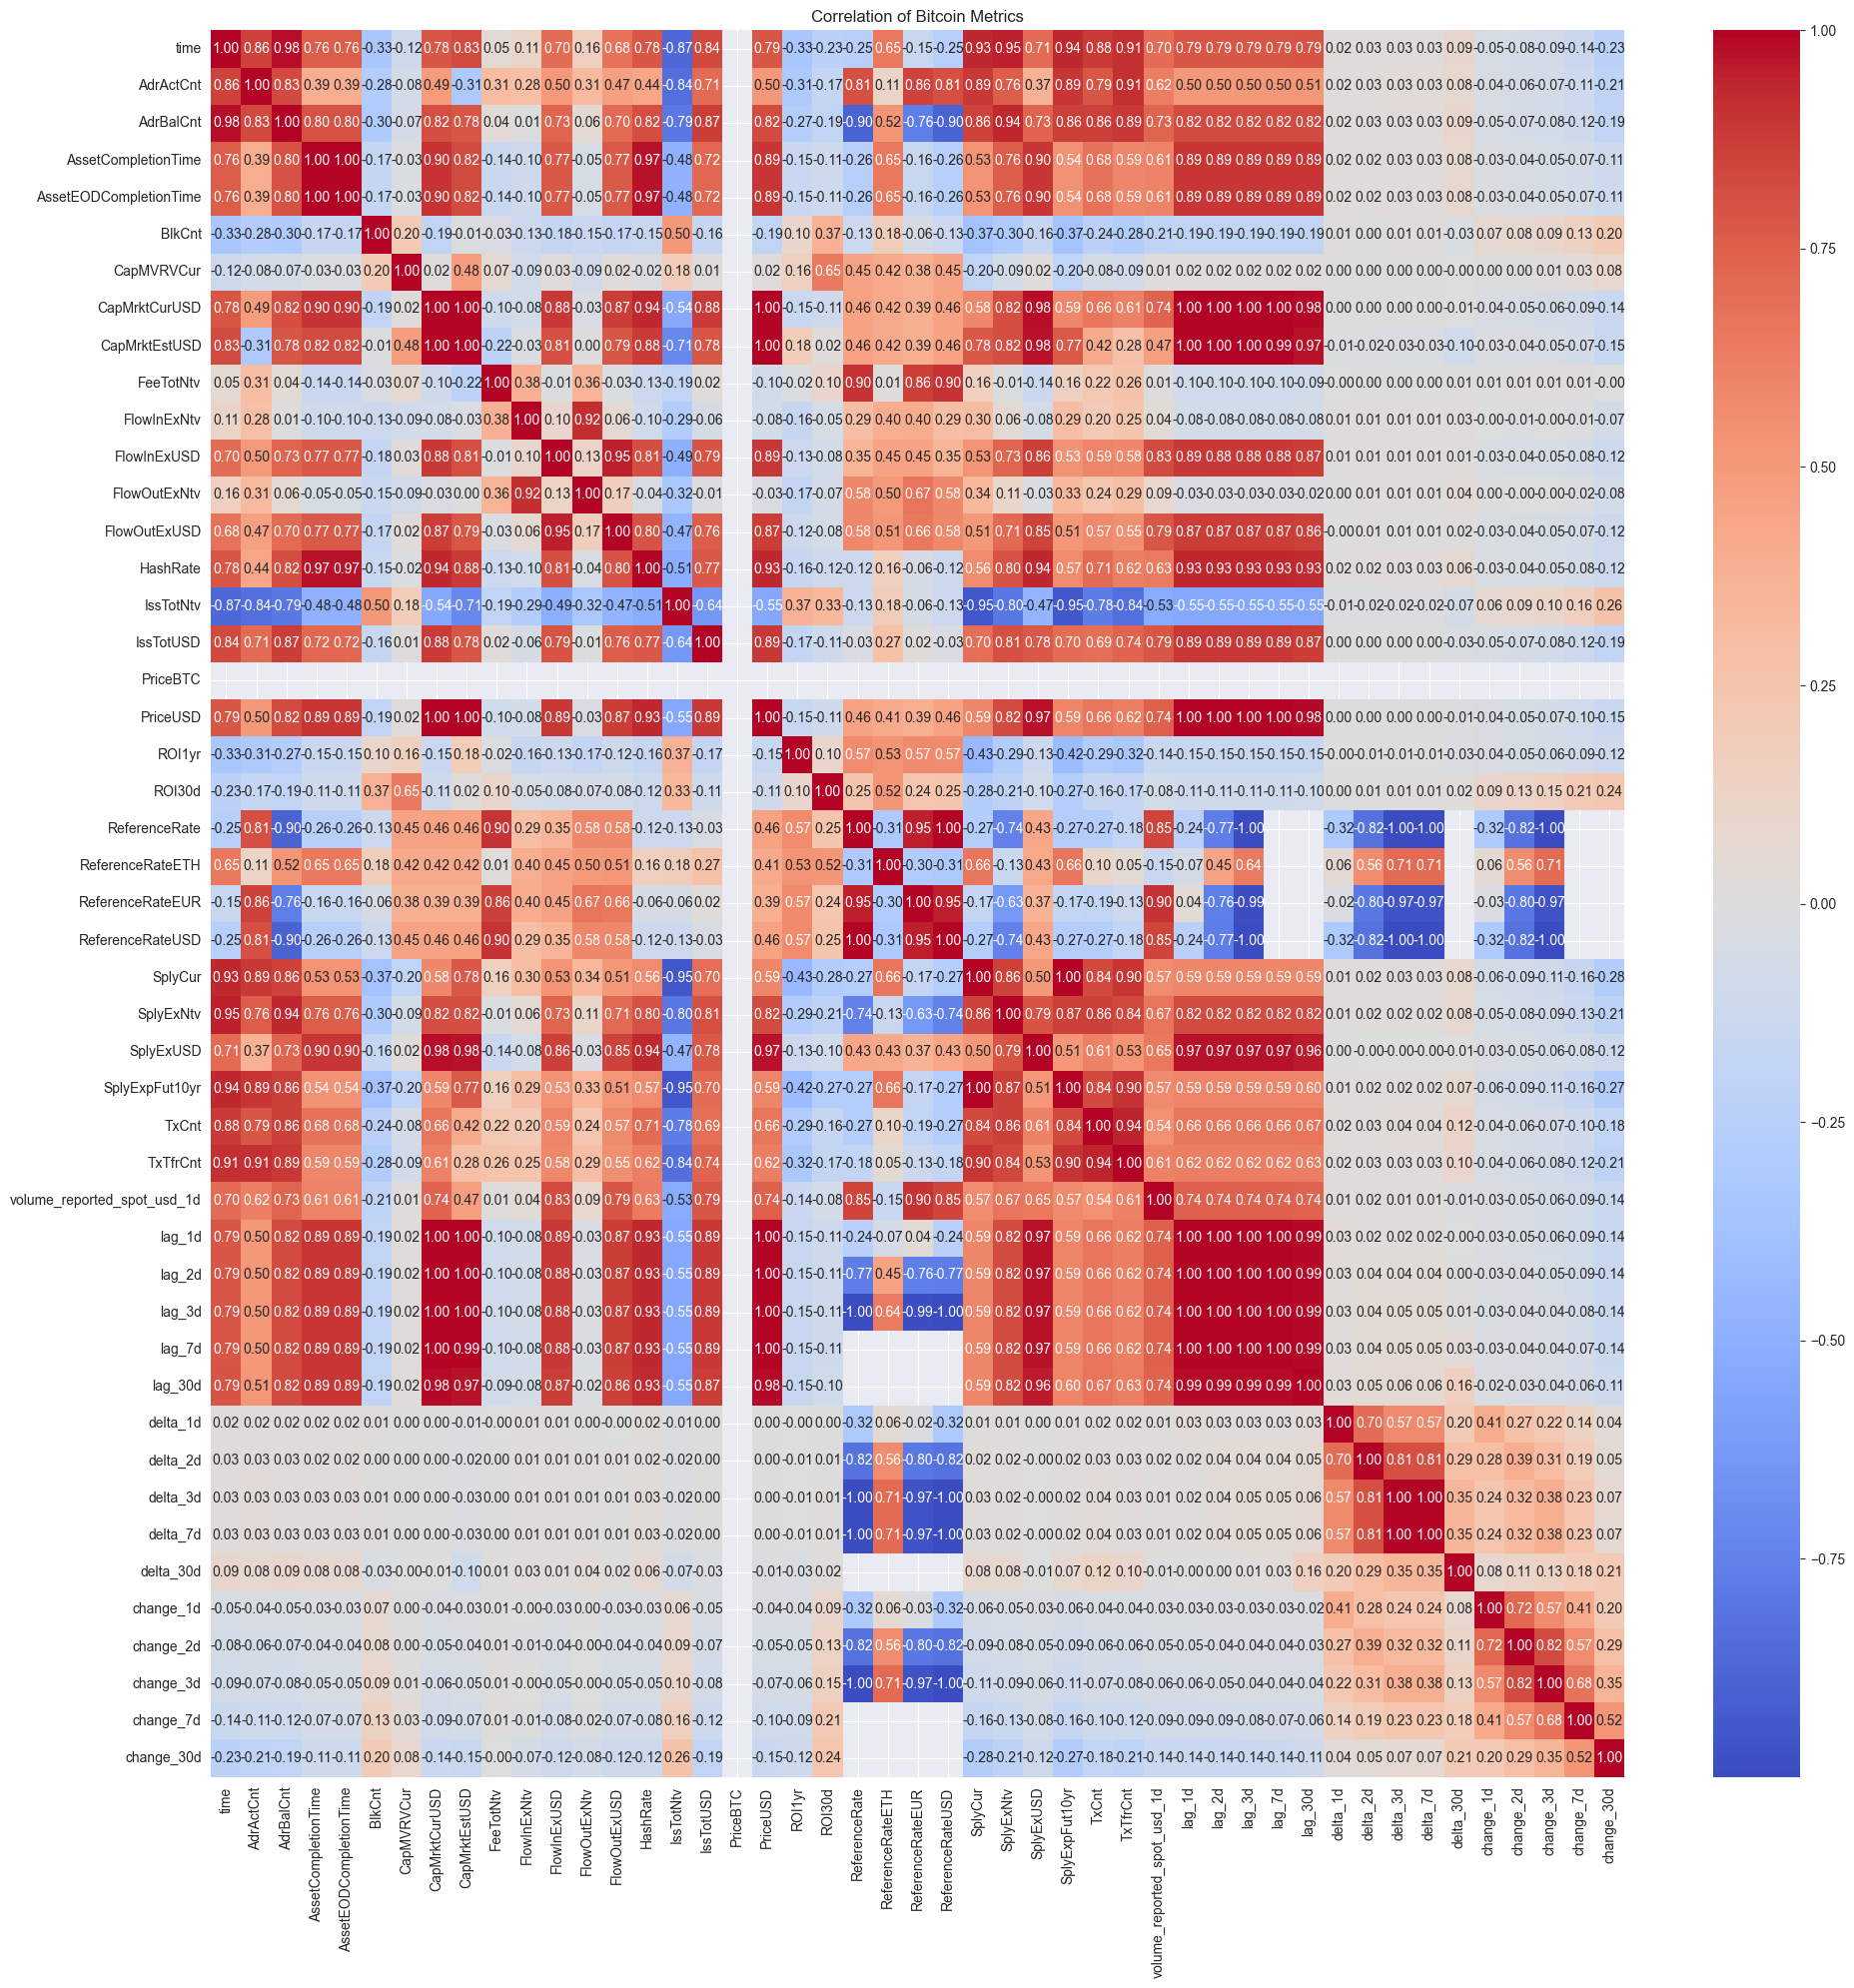

In [6]:
# Full correlation plot
plt.figure(figsize=(20, 20))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation of Bitcoin Metrics")
plt.tight_layout()

## Part 2: Polymarket data

Load dataset

In [7]:
data = eda.load_polymarket_data(eda.POLYMARKET_DIR)

Loading Polymarket data from C:\Users\timot\OneDrive\Learn\GT OMSA\Practicum\data\Polymarket...
[Memory] Before loading Polymarket data: 364.11 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
Loaded 156636 tokens records.
Loaded 27013724 trades records.
Loaded 44033 events records.
[Memory] After loading Polymarket data: 7.47 GB (Δ 7.12 GB)


### Markets data

In [8]:
markets_df = data.get("markets")

In [9]:
top_cats = (
    data["markets"].group_by("category")
    .agg(pl.col("market_id").count())
    .sort("market_id", descending=True)
    .head(20)
)
top_cats

category,market_id
str,u32
"""""",77516
"""Crypto""",340
"""US-current-affairs""",265
"""Business""",113
"""Global Politics""",56
…,…
"""Pop-Culture """,4
"""Coronavirus""",3
"""Tech""",2


In [10]:
# Cleanup and combine smaller categories
markets_df = markets_df.with_columns(
    pl.when(pl.col("category")=="Politics")
    .then(pl.lit("Global Politics"))
    .otherwise(pl.col("category"))
    .alias("category")
)
markets_df = markets_df.with_columns(
    pl.when(pl.col("category")=="Ukraine & Russia")
    .then(pl.lit("Global Politics"))
    .otherwise(pl.col("category"))
    .alias("category")
)
markets_df = markets_df.with_columns(
    pl.when(pl.col("category")=="Coronavirus-")
    .then(pl.lit("Other"))
    .otherwise(pl.col("category"))
    .alias("category")
)
markets_df = markets_df.with_columns(
    pl.when(pl.col("category")=="Pop-Culture ")
    .then(pl.lit("Other"))
    .otherwise(pl.col("category"))
    .alias("category")
)
markets_df = markets_df.with_columns(
    pl.when(pl.col("category")=="Coronavirus")
    .then(pl.lit("Other"))
    .otherwise(pl.col("category"))
    .alias("category")
)
markets_df = markets_df.with_columns(
    pl.when(pl.col("category")=="Tech")
    .then(pl.lit("Other"))
    .otherwise(pl.col("category"))
    .alias("category")
)

In [11]:
def categorize_blank(
    df: pl.DataFrame,
    model,
    textcol = "question",
    catcol = "category",
    unknown_label: str = "Other",
    threshold: float = 0.0
)-> pl.DataFrame:
    # Create mask for empty values
    mask = (pl.col(catcol) == "") | (pl.col(catcol).is_null())
    df_blank = df.filter(mask).select(textcol)
    texts = df_blank[textcol].to_list()

    # Predict
    preds = model.predict(texts)
    scores = model.decision_function(texts)
    scores = np.asarray(scores)

    # Multiclass margin handling
    if scores.ndim == 1:
        conf = np.abs(scores)
    else:
        conf = np.max(scores, axis=1)

    thresh_preds = np.where(conf >= threshold, preds, unknown_label)

    # Output
    df_idx = df.with_row_index("_idx")
    df_blank_idx = df_idx.filter(mask).select("_idx")
    pred_df = pl.DataFrame({
        "_idx": df_blank_idx["_idx"],
        "new_cat": thresh_preds.tolist()
    })

    out = (
        df_idx.join(pred_df, on="_idx", how="left")
        .with_columns(
            pl.when((pl.col(catcol)=="")|pl.col(catcol).is_null())
            .then(pl.col("new_cat"))
            .otherwise(pl.col(catcol))
            .alias(catcol)
        )
        .drop(["_idx","new_cat"])
    )
    return out

In [12]:
 # Training to identify correct category
markets_df_not_null = markets_df.filter(pl.col("category") != "")
texts = markets_df_not_null["question"]
labels = markets_df_not_null["category"]
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True,
        analyzer="word"
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

model.fit(X_train, y_train)
pred = model.predict(X_test)
print(classification_report(y_test, pred, digits=3))

                    precision    recall  f1-score   support

          Business      0.750     0.913     0.824        23
            Crypto      0.986     1.000     0.993        68
   Global Politics      0.750     0.400     0.522        15
             Other      1.000     0.500     0.667         2
US-current-affairs      0.927     0.962     0.944        53

          accuracy                          0.913       161
         macro avg      0.883     0.755     0.790       161
      weighted avg      0.911     0.913     0.905       161



In [13]:
markets_df_new = categorize_blank(markets_df, model)
markets_df_new.head()

market_id,question,slug,event_slug,category,volume,active,closed,created_at,end_date
str,str,str,str,str,f64,bool,bool,datetime[μs],datetime[μs]
"""242851""","""Will Bongbong Marcos be electe…","""will-bongbong-marcos-be-electe…","""will-bongbong-marcos-be-electe…","""Global Politics""",21533.53,true,true,2022-04-05 20:37:30,2022-05-09 00:00:00
"""242873""","""Will Sarah Palin win Alaska's …","""will-sarah-palin-win-in-the-al…","""will-sarah-palin-win-in-the-al…","""US-current-affairs""",79783.23,true,true,2022-04-05 22:41:57,2022-08-16 00:00:00
"""242918""","""Will US student loan payments …","""will-us-student-loan-payments-…","""will-us-student-loan-payments-…","""US-current-affairs""",18946.72,true,true,2022-04-05 23:33:47,2022-11-08 00:00:00
"""243183""","""Will $ETH be above $3,000 on A…","""will-eth-be-above-3000-on-apri…","""will-eth-be-above-3000-on-apri…","""Crypto""",974114.26,true,true,2022-04-12 16:51:10,2022-04-20 00:00:00
"""243192""","""Will Brian Kemp win the Republ…","""will-brian-kemp-win-the-republ…","""who-will-win-the-republican-no…","""US-current-affairs""",7024.92,true,true,2022-04-13 01:40:25,2022-05-24 00:00:00


Identify which markets are Bitcoin/BTC related and create new category

In [14]:
patterns_list = ["btc", "bitcoin"]
markets_df_new = markets_df_new.with_columns(
    pl.when(
        pl.col("question").str.contains_any(
            patterns_list,
            ascii_case_insensitive=True
        ) & (pl.col("category") == "Crypto")
    )
    .then(pl.lit("Bitcoin"))
    .otherwise(pl.col("category"))
    .alias("category")
)

In [15]:
top_cats = (
    markets_df_new.group_by("category")
    .agg(pl.col("market_id").count())
    .sort("market_id", descending=True)
)
top_cats

category,market_id
str,u32
"""Crypto""",37202
"""Bitcoin""",20408
"""US-current-affairs""",10447
"""Other""",8002
"""Global Politics""",2025
"""Business""",237


In [16]:
# Top markets by volume
top_cats_vol = (
    markets_df_new.group_by("category")
    .agg(pl.col("volume").sum())
    .sort("volume", descending=True)
)
top_cats_vol

category,volume
str,f64
"""US-current-affairs""",1.1056e10
"""Bitcoin""",2.2999e9
"""Global Politics""",1.8853e9
"""Crypto""",1.6230e9
"""Other""",1.2568e9
"""Business""",8.2824e7


**Sentiment analysis**

In [17]:
markets_df_bitcoin = markets_df_new.filter(pl.col("category")=="Bitcoin")

In [18]:
bullish_kw = [
    "reach", "approve", "hit", "sec approve", "ath", "all time high", "blackrock", "allow", "vanguard", "up or down",
     "approval", "above", "etf", "spot etf", "buy", "reach", "break", "rally","listed","purchase","hold", "acquires", "accepts"
]
bearish_kw = [
    "dips", "drop", "fall", "below", "dip",
    "reject", "deny", "lawsuit", "ban", "crackdown", "hack",
     "crash", "dump", "bear", "down", "not approve","sell", "liquidate"
]
neutral_kw = [
    "or", "better", "interview", "between",
    "which", "or", "first", "perform better", "vs", "versus",
    "say", "tweet", "0 times", "fees", "capture more", "single day fees", "less than"
]

In [19]:
def any_contains(col: pl.Expr, kws: list[str]) -> pl.Expr:
    # case-insensitive substring match
    return pl.any_horizontal([col.str.contains(rf"(?i){k}") for k in kws])

In [20]:
q = pl.col("question")

rule1 = (
    q.str.contains(r"(?i)hit")
    & q.str.contains(r"(?i)\sor\s")
    & q.str.contains(r"(?i)first")
)

rule2 = (
    q.str.contains(r"(?i)up")
    & q.str.contains(r"(?i)\sor\s")
    & q.str.contains(r"(?i)down")
)

markets_df_bitcoin_new = markets_df_bitcoin[:600].with_columns(
    pl.when(rule1)
      .then(pl.lit("neutral"))
    .when(rule2)
      .then(pl.lit("bullish"))
    .when(any_contains(q, bearish_kw))
      .then(pl.lit("bearish"))
    .when(any_contains(q, bullish_kw))
      .then(pl.lit("bullish"))
    .when(any_contains(q, neutral_kw))
      .then(pl.lit("neutral"))
    .otherwise(pl.lit("neutral"))  # default
    .alias("stance")
)

In [21]:
texts = markets_df_bitcoin_new["question"]
labels = markets_df_bitcoin_new["stance"]
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)

sentiment_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        min_df=2,
        max_df=0.9,
        sublinear_tf=True,
        analyzer="word"
    )),
    ("clf", LinearSVC(class_weight="balanced"))
])

sentiment_model.fit(X_train, y_train)
pred = sentiment_model.predict(X_test)
print(classification_report(y_test, pred, digits=3))

              precision    recall  f1-score   support

     bearish      1.000     1.000     1.000        14
     bullish      0.975     0.975     0.975        79
     neutral      0.926     0.926     0.926        27

    accuracy                          0.967       120
   macro avg      0.967     0.967     0.967       120
weighted avg      0.967     0.967     0.967       120



In [22]:
markets_df_bitcoin = markets_df_bitcoin.join(markets_df_bitcoin_new[["market_id","stance"]], on="market_id", how="left")
markets_df_bitcoin_new = categorize_blank(markets_df_bitcoin, sentiment_model, "question", "stance", "neutral")
markets_df_bitcoin_new = markets_df_bitcoin_new.with_columns(
    pl.when(pl.col("stance") == "neutral").then(0)
    .when(pl.col("stance") == "bullish").then(1)
    .when(pl.col("stance") == "bearish").then(-1)
    .alias("stance_val")
)


In [23]:
market_stance_cat = (
    markets_df_bitcoin_new.group_by("stance")
    .agg(pl.col("market_id").count())
    .sort("market_id", descending=True)
)
market_stance_cat

stance,market_id
str,u32
"""bullish""",14125
"""neutral""",5984
"""bearish""",299


In [24]:
if markets_df is not None:
    print(f"Total Markets: {len(markets_df)}")
    print(markets_df[:10])

    if "active" in markets_df.columns:
        active_count = markets_df["active"].sum()
        print(f"Active Markets: {active_count}")
        print(f"Closed Markets: {len(markets_df) - active_count}")

    if "volume" in markets_df.columns:
        total_volume = markets_df["volume"].sum()
        avg_volume = markets_df["volume"].mean()
        print(f"Total Volume: ${total_volume:,.2f}")
        print(f"Average Volume per Market: ${avg_volume:,.2f}")


Total Markets: 78321
shape: (10, 10)
┌───────────┬────────────┬────────────┬────────────┬───┬────────┬────────┬────────────┬────────────┐
│ market_id ┆ question   ┆ slug       ┆ event_slug ┆ … ┆ active ┆ closed ┆ created_at ┆ end_date   │
│ ---       ┆ ---        ┆ ---        ┆ ---        ┆   ┆ ---    ┆ ---    ┆ ---        ┆ ---        │
│ str       ┆ str        ┆ str        ┆ str        ┆   ┆ bool   ┆ bool   ┆ datetime[μ ┆ datetime[μ │
│           ┆            ┆            ┆            ┆   ┆        ┆        ┆ s]         ┆ s]         │
╞═══════════╪════════════╪════════════╪════════════╪═══╪════════╪════════╪════════════╪════════════╡
│ 242851    ┆ Will       ┆ will-bongb ┆ will-bongb ┆ … ┆ true   ┆ true   ┆ 2022-04-05 ┆ 2022-05-09 │
│           ┆ Bongbong   ┆ ong-marcos ┆ ong-marcos ┆   ┆        ┆        ┆ 20:37:30   ┆ 00:00:00   │
│           ┆ Marcos be  ┆ -be-electe ┆ -be-electe ┆   ┆        ┆        ┆            ┆            │
│           ┆ electe…    ┆ …          ┆ …          ┆  

### Tokens dataset

In [25]:
tokens_df = data.get("tokens")
tokens_df = tokens_df.join(markets_df_bitcoin_new["market_id","question","stance","stance_val"], on="market_id", how="left",)
tokens_df_bitcoin = tokens_df.filter(pl.col("question").is_not_null())

positive_kw = ["Yes","Long","Bitcoin","BTC","$BITCOIN","Up"]
negative_kw = ["No","Short","Down"]

q = pl.col("outcome")

tokens_df_bitcoin = tokens_df_bitcoin.with_columns(
    pl.when(any_contains(q, negative_kw))
      .then(-1)
    .when(any_contains(q, positive_kw))
      .then(1)
    .otherwise(0)  # default
    .alias("outcome_val")
)


### Trades dataset

Make final classification whether each trade is bullish/bearish/neutral

In [26]:
trades_df = data.get("trades")
trades_df_bitcoin = trades_df.join(tokens_df_bitcoin, on="token_id", how="left").filter(pl.col("question").is_not_null())
trades_df_bitcoin = trades_df_bitcoin.with_columns(
    pl.when(pl.col("side")=="BUY").then(1)
    .when(pl.col("side")=="SELL").then(-1)
    .otherwise(0)
    .alias("side_val")
)
trades_df_bitcoin = trades_df_bitcoin.with_columns((pl.col("side_val")*pl.col("stance_val")*pl.col("outcome_val")).alias("trade_val"))
trades_df_bitcoin

trade_id,market_id,token_id,timestamp,price,size,side,maker_address,taker_address,market_id_right,outcome,question,stance,stance_val,outcome_val,side_val,trade_val
str,str,str,datetime[μs],f64,f64,str,str,str,str,str,str,str,i32,i32,i32,i32
"""0x7a1c89afda0eba1f4134a9ee5f1e…","""608790""","""817673018336697223316686933682…",2025-09-23 04:31:56,0.5,50.0,"""BUY""","""0x5bcbecc81319e90ee671cab16cac…","""0xcc500cbcc8b7cf5bd21975ebbea3…","""608790""","""Up""","""Bitcoin Up or Down - September…","""bullish""",1,1,1,1
"""0xac0eb6c1e2662fa746642ce0588f…","""608790""","""817673018336697223316686933682…",2025-09-23 04:32:26,0.33,938.522387,"""BUY""","""0xcc500cbcc8b7cf5bd21975ebbea3…","""0xe90e35c00b3f03876c5f5be6bf28…","""608790""","""Up""","""Bitcoin Up or Down - September…","""bullish""",1,1,1,1
"""0x8366ec07fa1e390ec0e8cb7df808…","""608790""","""817673018336697223316686933682…",2025-09-23 04:32:30,0.3,5.0,"""BUY""","""0x54e544dd17e2e5b3f82123bfa303…","""0xcc500cbcc8b7cf5bd21975ebbea3…","""608790""","""Up""","""Bitcoin Up or Down - September…","""bullish""",1,1,1,1
"""0x8366ec07fa1e390ec0e8cb7df808…","""608790""","""817673018336697223316686933682…",2025-09-23 04:32:30,0.3,10.0,"""BUY""","""0x1d76ce5823ad7fd3de3a18b1a576…","""0xcc500cbcc8b7cf5bd21975ebbea3…","""608790""","""Up""","""Bitcoin Up or Down - September…","""bullish""",1,1,1,1
"""0x261864db70eccdc943ccfdbf2669…","""608790""","""817673018336697223316686933682…",2025-09-23 04:32:42,0.12,85.227266,"""BUY""","""0xcc500cbcc8b7cf5bd21975ebbea3…","""0x625689b0c128e4677f69857ef7d5…","""608790""","""Up""","""Bitcoin Up or Down - September…","""bullish""",1,1,1,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""0x1e016fdec5dace9a37e43571d5fd…","""692250""","""108547978327958467449318042977…",2026-01-05 03:29:49,0.047,300.0,"""SELL""","""""","""""","""692250""","""Yes""","""MicroStrategy sells any Bitcoi…","""neutral""",0,1,-1,0
"""0xe63c86338bc70c5d2131dffac218…","""701496""","""112916629048977131746679033883…",2026-01-05 04:27:51,0.187132,435.3615,"""BUY""","""""","""""","""701496""","""No""","""Will Bitcoin reach $100,000 by…","""bullish""",1,-1,1,-1
"""0xfe553caf7f71f42219b733ab3763…","""701496""","""112916629048977131746679033883…",2026-01-05 04:27:29,0.189351,3850.0,"""BUY""","""""","""""","""701496""","""No""","""Will Bitcoin reach $100,000 by…","""bullish""",1,-1,1,-1


In [27]:
trades_df_bitcoin = trades_df_bitcoin.with_columns(
    (pl.col("price")*pl.col("size")).alias("transaction"),
    (pl.col("size")*pl.col("trade_val")).alias("size_trade_val"),
    (pl.col("price")*pl.col("size")*pl.col("trade_val")).alias("transaction_trade_val")
)

Aggregate daily data

In [37]:
trades_df_bitcoin_day = trades_df_bitcoin.group_by(
    pl.col("timestamp").dt.date().alias("time")
).agg(
    pl.col("size").sum().alias("daily_volume"),
    pl.col("transaction").sum().alias("daily_transaction_value"),
    pl.col("size_trade_val").sum().alias("daily_netstance_volume"),
    pl.col("transaction_trade_val").sum().alias("daily_netstance_transaction_value"),
).sort("time")

trades_df_bitcoin_day = trades_df_bitcoin_day.with_columns(
    (pl.col("daily_netstance_volume")/pl.col("daily_volume")).alias("daily_sentiment_by_volume"),
    (pl.col("daily_netstance_transaction_value")/pl.col("daily_transaction_value")).alias("daily_sentiment_by_transaction_value")
)

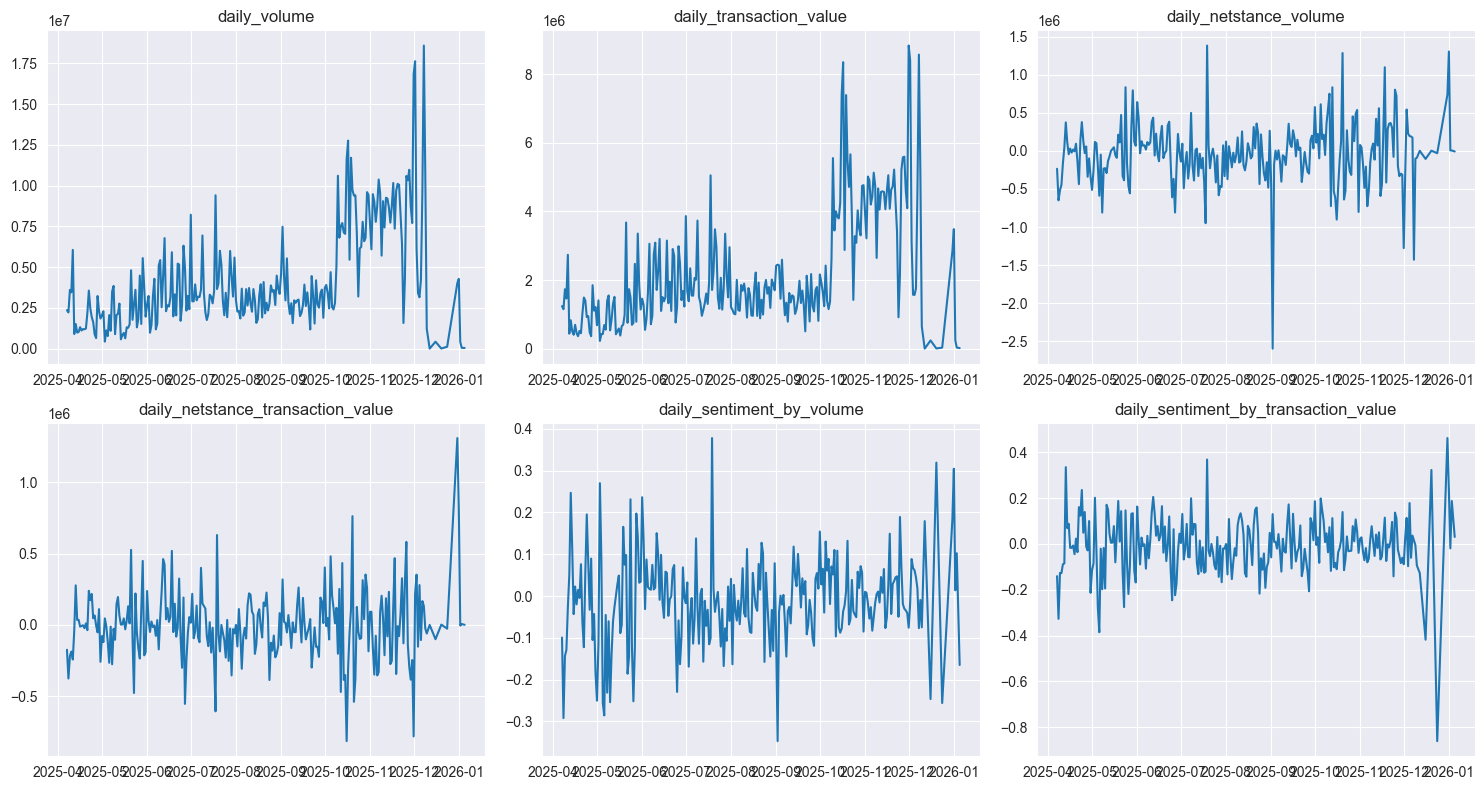

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

x = trades_df_bitcoin_day["time"]
cols = trades_df_bitcoin_day.columns[1:]

for i in range(2):
    for j in range(3):
        axes[i, j].plot(x, trades_df_bitcoin_day[cols[i*3+j]])
        axes[i, j].set_title(cols[i*3+j])

plt.tight_layout()
plt.show()

Merge Bitcoin price features

In [39]:
right_df = btc_df[["time","PriceUSD","lag_1d","lag_2d","lag_3d","lag_7d","lag_30d","delta_1d","delta_2d","delta_3d","delta_7d","delta_30d",
                                   "change_1d","change_2d","change_3d","change_7d","change_30d"]].with_columns(
    pl.col("time").cast(pl.Date)
)
trades_df_bitcoin_day=trades_df_bitcoin_day.join(right_df, on="time", how="left")

Correlation data does not seem super strong

In [40]:
corr2_df = trades_df_bitcoin_day.to_pandas()
corr2 = corr2_df.corr()
corr2

,time,daily_volume,daily_transaction_value,daily_netstance_volume,daily_netstance_transaction_value,daily_sentiment_by_volume,daily_sentiment_by_transaction_value,PriceUSD,lag_1d,lag_2d,...,delta_1d,delta_2d,delta_3d,delta_7d,delta_30d,change_1d,change_2d,change_3d,change_7d,change_30d
time,1.000000,0.523164,0.515780,0.071924,0.045667,0.119364,0.023710,0.045492,0.022555,-0.004987,...,-0.125081,-0.191343,-0.224145,-0.224145,-0.669605,-0.131997,-0.205899,-0.238580,-0.391601,-0.688798
daily_volume,0.523164,1.000000,0.983148,-0.153495,-0.075621,-0.005272,0.048142,-0.093933,-0.101945,-0.120799,...,-0.038165,-0.093004,-0.159990,-0.159990,-0.406600,-0.030518,-0.093009,-0.167366,-0.263046,-0.415913
daily_transaction_value,0.515780,0.983148,1.000000,-0.113210,-0.075366,0.024084,0.055478,-0.077625,-0.085240,-0.104109,...,-0.036862,-0.092803,-0.147557,-0.147557,-0.428848,-0.030097,-0.093645,-0.155438,-0.248877,-0.438159
daily_netstance_volume,0.071924,-0.153495,-0.113210,1.000000,0.686705,0.783879,0.506025,-0.010208,-0.015111,-0.027337,...,-0.025732,-0.063011,-0.034734,-0.034734,-0.070765,-0.032690,-0.069276,-0.043381,-0.059585,-0.067755
daily_netstance_transaction_value,0.045667,-0.075621,-0.075366,0.686705,1.000000,0.584128,0.732217,-0.011625,-0.003221,-0.023356,...,0.045578,-0.042807,-0.015579,-0.015579,0.016798,0.040882,-0.045408,-0.022997,-0.034825,0.012625
daily_sentiment_by_volume,0.119364,-0.005272,0.024084,0.783879,0.584128,1.000000,0.730757,-0.020274,-0.019649,-0.027314,...,0.004365,-0.024695,-0.040866,-0.040866,-0.084453,-0.004665,-0.029271,-0.051404,-0.078844,-0.083647
daily_sentiment_by_transaction_value,0.023710,0.048142,0.055478,0.506025,0.732217,0.730757,1.000000,0.054773,0.061147,0.048721,...,0.031361,-0.026631,-0.031701,-0.031701,-0.026888,0.026596,-0.028079,-0.041188,-0.054314,-0.030203
PriceUSD,0.045492,-0.093933,-0.077625,-0.010208,-0.011625,-0.020274,0.054773,1.000000,0.982760,0.964838,...,-0.142621,-0.205679,-0.241457,-0.241457,-0.523220,-0.155148,-0.225476,-0.262613,-0.336725,-0.549762
lag_1d,0.022555,-0.101945,-0.085240,-0.015111,-0.003221,-0.019649,0.061147,0.982760,1.000000,0.982278,...,0.042834,-0.075270,-0.138154,-0.138154,-0.483911,0.028526,-0.095860,-0.158938,-0.267145,-0.509964
lag_2d,-0.004987,-0.120799,-0.104109,-0.027337,-0.023356,-0.027314,0.048721,0.964838,0.982278,1.000000,...,0.044808,0.058778,-0.025701,-0.025701,-0.443177,0.027647,0.036675,-0.049088,-0.197171,-0.470104


### Odds dataset and others

In [42]:
odds_df = data.get("odds")
odds_df.head(10)

market_id,token_id,timestamp,price
str,str,datetime[μs],f64
"""255140""","""474357953615233060686693901910…",2024-06-08 00:00:02,0.055
"""255140""","""474357953615233060686693901910…",2024-06-09 00:00:03,0.055
"""255140""","""474357953615233060686693901910…",2024-06-10 00:00:04,0.055
"""255140""","""474357953615233060686693901910…",2024-06-11 00:00:02,0.055
"""255140""","""474357953615233060686693901910…",2024-06-12 00:00:03,0.055
"""255140""","""474357953615233060686693901910…",2024-06-13 00:00:03,0.055
"""255140""","""474357953615233060686693901910…",2024-06-14 00:00:03,0.055
"""255140""","""474357953615233060686693901910…",2024-06-15 00:00:04,0.055
"""255140""","""474357953615233060686693901910…",2024-06-16 00:00:04,0.055


In [43]:
tokens_df = data.get("tokens")
if tokens_df is not None:
    print(f"Total Tokens: {len(tokens_df)}")
    print(tokens_df.head())

trades_df = data.get("trades")
if trades_df is not None:
    print(f"Total Trades: {len(trades_df)}")
    print(trades_df.head())

odds_df = data.get("odds")
if odds_df is not None:
    print(f"Total Odds History Records: {len(odds_df):,}")
    print(odds_df.head(30))

event_df = data.get("events")
if event_df is not None:
    print(f"Total Events: {len(event_df)}")
    print(event_df.head())

summary_df = data.get("summary")
if summary_df is not None and "trade_count" in summary_df.columns:
    total_trades = summary_df["trade_count"].sum()
    print(f"Total Trades: {total_trades:,}")

Total Tokens: 156636
shape: (5, 3)
┌───────────┬─────────────────────────────────┬─────────┐
│ market_id ┆ token_id                        ┆ outcome │
│ ---       ┆ ---                             ┆ ---     │
│ str       ┆ str                             ┆ str     │
╞═══════════╪═════════════════════════════════╪═════════╡
│ 240383    ┆ 555875344331027638590324435858… ┆ Yes     │
│ 240383    ┆ 111837615529992437689409005124… ┆ No      │
│ 240384    ┆ 113459643164060403919504712048… ┆ Yes     │
│ 240384    ┆ 110606609354376812966157988257… ┆ No      │
│ 240385    ┆ 505435736314143687770680977181… ┆ Yes     │
└───────────┴─────────────────────────────────┴─────────┘
Total Trades: 27013724
shape: (5, 9)
┌────────────┬───────────┬────────────┬────────────┬───┬────────────┬──────┬───────────┬───────────┐
│ trade_id   ┆ market_id ┆ token_id   ┆ timestamp  ┆ … ┆ size       ┆ side ┆ maker_add ┆ taker_add │
│ ---        ┆ ---       ┆ ---        ┆ ---        ┆   ┆ ---        ┆ ---  ┆ ress      ┆

### XGBoost test

In [44]:
X = btc_df.to_pandas().iloc[:,1:32]
y = btc_df.to_pandas()["change_7d"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, shuffle=False)
bst = XGBRegressor(n_estimators=200, max_depth=3)
bst.fit(X_train, y_train)
preds = bst.predict(X_test)

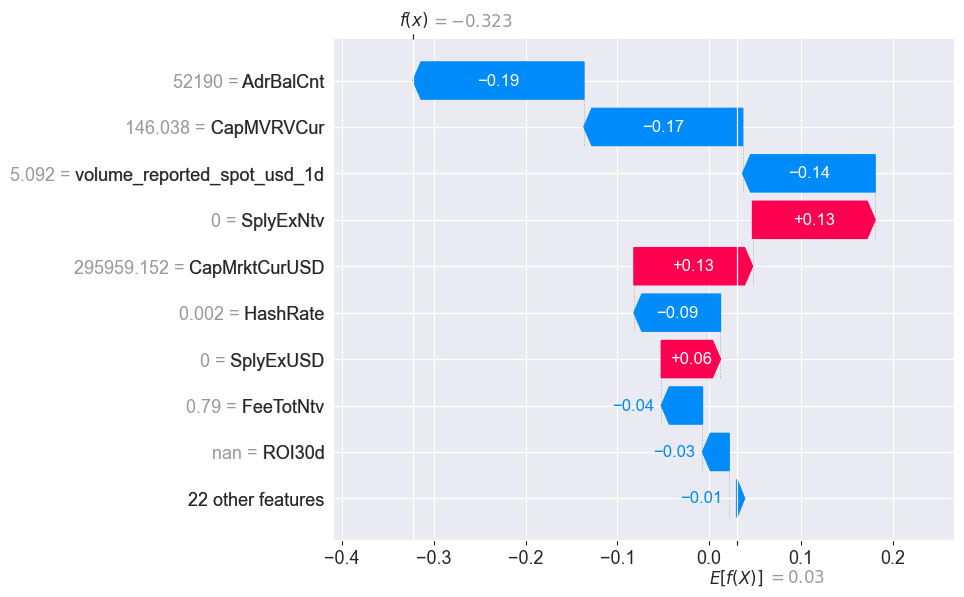

In [45]:
# Explain the model's predictions
explainer = shap.Explainer(bst)
shap_values = explainer(X)

# Visualize the first prediction
shap.plots.waterfall(shap_values[0])

## Other data sources/analyses

Seasonality